# Notebook 02 — Data Preparation
## FYP: Adaptive Explainable Ensemble for Pre-Launch Steam Game Reception Prediction
### Heshan Ratnaweera | IIT Sri Lanka | W2082289 | 2026

**Purpose:** Transform the raw Steam dataset into a clean, fully-encoded feature matrix ready for modelling.
This is the only notebook that writes to `data/processed/`. All subsequent notebooks read from its output.

**Inputs:** `data/raw/Dataset-2.csv`
**Outputs:** `data/processed/games_features_t4.csv`
**Key results:** *(fill in after running — e.g. "20,383 games × 54 features, 0 nulls")*

---
## Contents
1. Setup & Imports
2. Load & Filter Raw Dataset
3. Drop Unwanted Columns
4. Fix Sentinel Values & Cap Outliers
5. Derive Simple Features
6. Parse String Columns to Counts
7. One-Hot Encode Genres (Top 10)
8. One-Hot Encode Tags (Top 20)
9. One-Hot Encode Categories (Key 12)
10. Drop Raw Source Columns
11. Final Verification & Save
12. Feature Summary


## 1. Setup & Imports

In [1]:
import sys
import ast
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Add project root to path so we can import src/config.py ───────────────────
# __file__ is not defined in Jupyter — use Path.cwd() instead
# Navigate from notebooks/ up to the project root
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    RAW_CSV, FEATURES_T4_CSV, FILTERED_CSV,
    MIN_REVIEW_COUNT, POSITIVE_THRESHOLD, TARGET_COL,
    COL_LABEL, COL_FILTER, COL_PRICE, COL_AGE, COL_DLC,
    COL_GENRES, COL_TAGS, COL_CATS, COL_MAC, COL_LINUX,
    COL_LANGS, COL_SCREENSHOTS, COL_MOVIES,
    COL_ACHIEVEMENTS, COL_WEBSITE, COL_DESC,
    DLC_CAP, AGE_SENTINEL, SCREENSHOT_CAP, MOVIE_CAP, LANG_COUNT_CAP,
    TOP_10_GENRES, TOP_20_TAGS, KEY_CATEGORIES,
    RANDOM_STATE
)

# Ensure processed output directory exists
FEATURES_T4_CSV.parent.mkdir(parents=True, exist_ok=True)

print('Imports OK')
print(f'Project root : {PROJECT_ROOT}')
print(f'Raw CSV      : {RAW_CSV}')
print(f'Output CSV   : {FEATURES_T4_CSV}')


Imports OK
Project root : C:\Users\3214h\Documents\fyp-steam-reception
Raw CSV      : C:\Users\3214h\Documents\fyp-steam-reception\data\raw\Dataset-2.csv
Output CSV   : C:\Users\3214h\Documents\fyp-steam-reception\data\processed\games_features_t4.csv


## 2. Load & Filter Raw Dataset

Three steps in sequence:
1. Load the raw CSV
2. Remove rows where `num_reviews_total == -1` (sentinel for "no review data")
3. Keep only games with ≥100 reviews (ensures statistically reliable labels)

The ≥100 threshold is defined in the proposal. `num_reviews_total` is a filter gate only —
it is never used as a model feature (post-launch data).


In [2]:
# ── Load raw CSV ──────────────────────────────────────────────────────────────
assert RAW_CSV.exists(), f'Dataset not found at {RAW_CSV}. Download from Kaggle.'
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
print(f'Raw dataset loaded : {len(df_raw):,} rows × {df_raw.shape[1]} columns')

# ── Step 1: Remove -1 sentinel rows ───────────────────────────────────────────
# num_reviews_total uses -1 to mean "no review data available for this game"
# These rows cannot be labelled reliably — remove them first
df_raw[COL_FILTER] = pd.to_numeric(df_raw[COL_FILTER], errors='coerce')
df = df_raw[df_raw[COL_FILTER] > 0].copy()
print(f'After -1 sentinel removal : {len(df):,} games')

# ── Step 2: Apply ≥100 review filter ──────────────────────────────────────────
# A game with 3 reviews at 100% positive is not comparable to one with 50,000 at 75%.
# The 100-review threshold ensures all labels are statistically meaningful.
df = df[df[COL_FILTER] >= MIN_REVIEW_COUNT].copy()
print(f'After ≥{MIN_REVIEW_COUNT} review filter : {len(df):,} games  ({len(df)/len(df_raw)*100:.1f}% of raw)')

# ── Step 3: Create binary label ────────────────────────────────────────────────
# pct_pos_total is stored as 0–100 integer (e.g. 86 means 86% positive)
# Normalise to 0.0–1.0 ratio, then apply the 75% threshold
df[COL_LABEL] = pd.to_numeric(df[COL_LABEL], errors='coerce')
df['positive_ratio'] = df[COL_LABEL] / 100.0
df[TARGET_COL] = (df['positive_ratio'] >= POSITIVE_THRESHOLD).astype(int)

# ── Confirm class balance ──────────────────────────────────────────────────────
counts = df[TARGET_COL].value_counts()
print(f'\nClass distribution:')
print(f'  Well Received   (label=1): {counts.get(1,0):>6,}  ({counts.get(1,0)/len(df)*100:.1f}%)')
print(f'  Not Well Received (label=0): {counts.get(0,0):>6,}  ({counts.get(0,0)/len(df)*100:.1f}%)')
print(f'\nExpected: ~14,631 / 71.8% and ~5,752 / 28.2%')


Raw dataset loaded : 89,618 rows × 47 columns
After -1 sentinel removal : 53,199 games
After ≥100 review filter : 20,383 games  (22.7% of raw)

Class distribution:
  Well Received   (label=1): 14,631  (71.8%)
  Not Well Received (label=0):  5,752  (28.2%)

Expected: ~14,631 / 71.8% and ~5,752 / 28.2%


## 3. Drop Unwanted Columns

31 columns are dropped based on decisions made in notebook 01:
- **Post-launch data** — would be data leakage as features
- **Metadata / URLs** — not structured features
- **Zero variance** — `windows` (100% of games support it)
- **Redundant text** — `detailed_description` and `about_the_game` duplicate `short_description`
- **Not significant** — `full_audio_languages` (r=0.008, p=0.277)

We keep only the 15 columns that will become features or are needed for label/filter.


In [3]:
# ── Columns to keep (confirmed in notebook 01 DECISIONS dict) ────────────────
# This is an explicit keep-list — safer than a drop-list because it prevents
# accidentally keeping new columns if the dataset is updated
KEEP_COLS = [
    TARGET_COL,         # reception_label (already created above)
    'positive_ratio',   # kept temporarily for verification; dropped at end
    COL_PRICE,          # price
    COL_AGE,            # required_age   (has -1 sentinel — fixed in step 4)
    COL_DLC,            # dlc_count      (used only for price_to_dlc_ratio)
    COL_GENRES,         # genres         (parsed to one-hot in step 7)
    COL_TAGS,           # tags           (parsed to one-hot in step 8)
    COL_CATS,           # categories     (parsed to one-hot in step 9)
    COL_MAC,            # mac            (feeds platform_coverage)
    COL_LINUX,          # linux          (feeds platform_coverage)
    COL_LANGS,          # supported_languages (parsed to count in step 6)
    COL_SCREENSHOTS,    # screenshots    (parsed to count in step 6)
    COL_MOVIES,         # movies         (parsed to count in step 6)
    COL_ACHIEVEMENTS,   # achievements   (converted to binary in step 5)
    COL_WEBSITE,        # website        (converted to binary in step 5)
    COL_DESC,           # short_description (kept for Model E in notebook 05)
]

# Confirm all expected columns exist before dropping
missing = [c for c in KEEP_COLS if c not in df.columns]
if missing:
    print(f'WARNING — columns not found in DataFrame: {missing}')
else:
    print('All expected columns present ✓')

df = df[KEEP_COLS].copy()

print(f'\nAfter column drop: {df.shape[1]} columns remaining')
print(f'Columns kept: {df.columns.tolist()}')


All expected columns present ✓

After column drop: 16 columns remaining
Columns kept: ['reception_label', 'positive_ratio', 'price', 'required_age', 'dlc_count', 'genres', 'tags', 'categories', 'mac', 'linux', 'supported_languages', 'screenshots', 'movies', 'achievements', 'website', 'short_description']


## 4. Fix Sentinel Values & Cap Outliers

**Sentinel fix:**
- `required_age` uses -1 to mean "no age restriction set" — replace with 0

**Outlier caps** (based on actual data distributions from notebook 01):
- `dlc_count`: max is 3,427 but 75th percentile is 1 — cap at 50 to prevent
  `price_to_dlc_ratio` from collapsing to near-zero on extreme cases
- `screenshot_count`: Steam's hard limit is 20 screenshots — max of 183 in data
  is a parsing artefact; cap at 20
- `movie_count`: max is 47, 75th percentile is 2 — cap at 10
- `supported_languages_count`: max is 103, 75th percentile is 9 — cap at 30

**No cap needed for:**
- `price`: tree models are robust to outliers; only 41 games above $60 (0.2%)
- `achievements`: converted to binary flag in step 5; raw value irrelevant


In [4]:
# ── Ensure numerical columns are the right dtype ──────────────────────────────
for col in [COL_PRICE, COL_AGE, COL_DLC, COL_ACHIEVEMENTS]:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# ── Fix required_age sentinel ──────────────────────────────────────────────────
# -1 means "age restriction not set by developer" — treat as 0 (unrestricted)
n_sentinel = (df[COL_AGE] == AGE_SENTINEL).sum()
df[COL_AGE] = df[COL_AGE].replace(AGE_SENTINEL, 0)
print(f'required_age: replaced {n_sentinel} sentinel (-1) values with 0')
print(f'  New range: {df[COL_AGE].min()} to {df[COL_AGE].max()}')

# ── Cap dlc_count ──────────────────────────────────────────────────────────────
n_above_dlc = (df[COL_DLC] > DLC_CAP).sum()
df[COL_DLC] = df[COL_DLC].clip(0, DLC_CAP)
print(f'\ndlc_count: capped {n_above_dlc} games above {DLC_CAP} → new max = {df[COL_DLC].max()}')

# ── Verify price (no cap — just confirm range is sensible) ─────────────────────
print(f'\nprice: min={df[COL_PRICE].min()}, max={df[COL_PRICE].max():.2f}, '
      f'median={df[COL_PRICE].median():.2f}')
print(f'  Games above $60: {(df[COL_PRICE] > 60).sum()} (no cap applied — tree models robust)')

print('\nOutlier/sentinel fixes applied ✓')


required_age: replaced 1 sentinel (-1) values with 0
  New range: 0 to 18

dlc_count: capped 62 games above 50 → new max = 50

price: min=0.0, max=89.99, median=7.99
  Games above $60: 41 (no cap applied — tree models robust)

Outlier/sentinel fixes applied ✓


## 5. Derive Simple Features

Six derived features are created here:

| Feature | Formula | Rationale |
|---|---|---|
| `is_free` | `price == 0 → 1` | Free games have lower reception (65.5% vs 73.4%) |
| `price_to_dlc_ratio` | `price / (dlc_count + 1)` | Separates monetisation strategies |
| `platform_coverage` | `(mac + linux) / 2` | Strongest individual signal (r=0.107) |
| `has_achievements` | `achievements > 0 → 1` | 64.7% vs 74.4% well-received; raw count not significant |
| `has_website` | `website not empty → 1` | Marketing investment proxy |
| `genre_concentration` | `genres_assigned / 10` | How focused/unfocused the genre mix is |

`windows` is NOT included in `platform_coverage` — 100% of games support Windows (zero variance).


In [5]:
# ── is_free ────────────────────────────────────────────────────────────────────
# A game is free-to-play if its listed price is exactly $0.00
# This column does not exist in the raw CSV — derived from price
df['is_free'] = (df[COL_PRICE] == 0.0).astype(int)
n_free = df['is_free'].sum()
print(f'is_free: {n_free:,} games ({n_free/len(df)*100:.1f}%)')

# ── price_to_dlc_ratio ─────────────────────────────────────────────────────────
# +1 in denominator prevents division by zero when dlc_count = 0
# Captures the relationship between base game price and DLC monetisation depth
df['price_to_dlc_ratio'] = df[COL_PRICE] / (df[COL_DLC] + 1)
print(f'\nprice_to_dlc_ratio: mean={df["price_to_dlc_ratio"].mean():.2f}, '
      f'median={df["price_to_dlc_ratio"].median():.2f}, '
      f'max={df["price_to_dlc_ratio"].max():.2f}')

# ── platform_coverage ──────────────────────────────────────────────────────────
# windows is excluded — 100% of games support it, adding zero information
# mac and linux each correlate positively with reception (r≈0.097 and 0.094)
df[COL_MAC]   = df[COL_MAC].map(lambda x: 1 if str(x).strip().lower() in ('true','1','yes') else 0)
df[COL_LINUX] = df[COL_LINUX].map(lambda x: 1 if str(x).strip().lower() in ('true','1','yes') else 0)
df['platform_coverage'] = (df[COL_MAC] + df[COL_LINUX]) / 2
print(f'\nplatform_coverage distribution:')
print(df['platform_coverage'].value_counts().sort_index())

# ── has_achievements ───────────────────────────────────────────────────────────
# Raw achievement count is not significant (r=-0.006, p=0.430)
# Binary version IS significant (r=0.095, p<0.001)
# 0 achievements → 64.7% well-received vs >0 achievements → 74.4% well-received
df['has_achievements'] = (df[COL_ACHIEVEMENTS] > 0).astype(int)
n_has = df['has_achievements'].sum()
print(f'\nhas_achievements: {n_has:,} games have achievements ({n_has/len(df)*100:.1f}%)')

# ── has_website ────────────────────────────────────────────────────────────────
# Binary flag: does the game have a dedicated website?
# r=-0.021 (games with websites are slightly less well-received — larger studios, higher expectations)
df['has_website'] = df[COL_WEBSITE].apply(
    lambda x: 0 if (pd.isna(x) or str(x).strip() == '') else 1
)
n_web = df['has_website'].sum()
print(f'has_website: {n_web:,} games have a website ({n_web/len(df)*100:.1f}%)')

# ── genre_concentration ────────────────────────────────────────────────────────
# Measures how spread across genres a game is
# genres_assigned / 10 (normalised by our top-10 ceiling → 0.0 to 1.0+)
# Will be computed properly in step 7 after parsing genres
# Placeholder created here; overwritten in step 7
df['genre_concentration'] = 0.0
print(f'\ngenre_concentration: placeholder created (will be set in step 7)')

print('\nAll simple derived features created ✓')


is_free: 4,268 games (20.9%)

price_to_dlc_ratio: mean=7.07, median=4.99, max=89.99

platform_coverage distribution:
platform_coverage
0.0000    13793
0.5000     3135
1.0000     3455
Name: count, dtype: int64

has_achievements: 14,952 games have achievements (73.4%)
has_website: 13,036 games have a website (64.0%)

genre_concentration: placeholder created (will be set in step 7)

All simple derived features created ✓


## 6. Parse String Columns to Counts

Three columns contain string-encoded lists that we parse to integer counts:

- `supported_languages` → `supported_languages_count` (capped at 30)
- `screenshots` → `screenshot_count` (capped at 20 — Steam's hard limit)
- `movies` → `movie_count` (capped at 10)

These use `safe_list_len()` which handles the string-encoded list format safely.


In [6]:
def safe_list_len(val):
    """
    Safely parse a string-encoded list and return its length.
    Handles both list format ['a','b'] and dict format {'a':1,'b':2}.
    Returns 0 for null, empty, or unparseable values.
    """
    if pd.isna(val) or str(val).strip() in ('', '[]', '{}'):
        return 0
    try:
        result = ast.literal_eval(str(val))
        if isinstance(result, (list, dict)):
            return len(result)
        return 0
    except Exception:
        return 0


def count_languages(val):
    """
    Parse the supported_languages column.
    Handles both list format and comma-separated string format.
    """
    if pd.isna(val) or str(val).strip() in ('', '[]'):
        return 0
    try:
        result = ast.literal_eval(str(val))
        return len(result) if isinstance(result, list) else 1
    except Exception:
        # Fallback: count comma-separated items
        return len([x for x in str(val).split(',') if x.strip()])


# ── supported_languages_count ──────────────────────────────────────────────────
df['supported_languages_count'] = df[COL_LANGS].apply(count_languages)
n_before_cap = (df['supported_languages_count'] > LANG_COUNT_CAP).sum()
df['supported_languages_count'] = df['supported_languages_count'].clip(0, LANG_COUNT_CAP)
print(f'supported_languages_count:')
print(f'  median={df["supported_languages_count"].median():.0f}, '
      f'max={df["supported_languages_count"].max()}, '
      f'capped {n_before_cap} games above {LANG_COUNT_CAP}')

# ── screenshot_count ───────────────────────────────────────────────────────────
# Steam's hard limit is 20 screenshots per store page
# Values above 20 are parsing artefacts from the dataset collection process
df['screenshot_count'] = df[COL_SCREENSHOTS].apply(safe_list_len)
n_before_cap = (df['screenshot_count'] > SCREENSHOT_CAP).sum()
df['screenshot_count'] = df['screenshot_count'].clip(0, SCREENSHOT_CAP)
print(f'\nscreenshot_count:')
print(f'  median={df["screenshot_count"].median():.0f}, '
      f'max={df["screenshot_count"].max()}, '
      f'capped {n_before_cap} games above {SCREENSHOT_CAP}')

# ── movie_count ────────────────────────────────────────────────────────────────
df['movie_count'] = df[COL_MOVIES].apply(safe_list_len)
n_before_cap = (df['movie_count'] > MOVIE_CAP).sum()
df['movie_count'] = df['movie_count'].clip(0, MOVIE_CAP)
print(f'\nmovie_count:')
print(f'  median={df["movie_count"].median():.0f}, '
      f'max={df["movie_count"].max()}, '
      f'capped {n_before_cap} games above {MOVIE_CAP}')

print('\nAll count features parsed ✓')


supported_languages_count:
  median=4, max=30, capped 242 games above 30

screenshot_count:
  median=9, max=20, capped 1203 games above 20

movie_count:
  median=1, max=10, capped 80 games above 10

All count features parsed ✓


## 7. One-Hot Encode Genres (Top 10)

Genres are stored as string-encoded Python lists: `"['Action', 'RPG']"`

We create 10 binary columns — one per genre from `TOP_10_GENRES` in `config.py`.
We also compute `genre_concentration` here since we need the parsed genre lists.

**Column naming:** `genre_Indie`, `genre_Action`, etc. (spaces → underscores)


In [7]:
def parse_list_col(series_val):
    """
    Parse a single string-encoded list value into a Python list.
    Used for genres and categories (stored as ['Action', 'RPG'] format).
    """
    if pd.isna(series_val) or str(series_val).strip() in ('', '[]', '{}'):
        return []
    try:
        result = ast.literal_eval(str(series_val))
        if isinstance(result, list):
            return [str(x).strip() for x in result]
        elif isinstance(result, str):
            return [result.strip()]
        return []
    except Exception:
        items = [x.strip().strip("'\")") for x in str(series_val).split(',') if x.strip()]
        return items


# ── Parse genres column ────────────────────────────────────────────────────────
df['_genres_parsed'] = df[COL_GENRES].apply(parse_list_col)

# ── genre_concentration ────────────────────────────────────────────────────────
# Normalise genre count by 10 (our one-hot ceiling) → 0.0 to 1.0+
# A game with 10 genres gets 1.0, a game with 1 genre gets 0.1
# Clip at 1.0 since 11 genres would otherwise exceed the scale
df['genre_concentration'] = (df['_genres_parsed'].apply(len) / 10).clip(0, 1.0)
print(f'genre_concentration: mean={df["genre_concentration"].mean():.3f}, '
      f'median={df["genre_concentration"].median():.3f}')

# ── Create one-hot columns for top 10 genres ──────────────────────────────────
print(f'\nCreating {len(TOP_10_GENRES)} genre one-hot columns:')
genre_cols_created = []
for genre in TOP_10_GENRES:
    col_name = f'genre_{genre.replace(" ", "_").replace("-", "_")}'
    df[col_name] = df['_genres_parsed'].apply(lambda lst: 1 if genre in lst else 0)
    coverage = df[col_name].sum()
    rate = df.loc[df[col_name] == 1, TARGET_COL].mean()
    print(f'  {col_name:<35} n={coverage:>6,}  well_received={rate:.3f}')
    genre_cols_created.append(col_name)

print(f'\nGenre encoding complete: {len(genre_cols_created)} columns created ✓')


genre_concentration: mean=0.294, median=0.300

Creating 10 genre one-hot columns:
  genre_Indie                         n=13,600  well_received=0.748
  genre_Adventure                     n= 8,896  well_received=0.734
  genre_Action                        n= 8,392  well_received=0.686
  genre_Casual                        n= 6,771  well_received=0.759
  genre_Simulation                    n= 5,340  well_received=0.659
  genre_RPG                           n= 5,076  well_received=0.671
  genre_Strategy                      n= 4,515  well_received=0.652
  genre_Free_To_Play                  n= 3,127  well_received=0.643
  genre_Early_Access                  n= 1,653  well_received=0.619
  genre_Massively_Multiplayer         n=   898  well_received=0.362

Genre encoding complete: 10 columns created ✓


## 8. One-Hot Encode Tags (Top 20)

Tags are stored differently from genres — as **dicts with vote counts**:
`"{'Singleplayer': 11869, 'Indie': 10091, ...}"`

We extract only the tag names (keys) and discard the vote counts.
Then create 20 binary columns using `TOP_20_TAGS` from `config.py`.

Note: 2,639 games (12.9%) have no tags at all — documented as a limitation.


In [8]:
def parse_tags_col(val):
    """
    Parse the tags column (stored as a dict with vote counts) into a list of tag names.
    Input:  "{'FPS': 90857, 'Shooter': 65397}"
    Output: ['FPS', 'Shooter']
    """
    if pd.isna(val) or str(val).strip() in ('', '[]', '{}'):
        return []
    try:
        result = ast.literal_eval(str(val))
        if isinstance(result, dict):
            # Extract only the key names — vote counts are discarded
            return list(result.keys())
        elif isinstance(result, list):
            return [str(x).strip() for x in result]
        return []
    except Exception:
        return []


# ── Parse tags column ──────────────────────────────────────────────────────────
df['_tags_parsed'] = df[COL_TAGS].apply(parse_tags_col)

n_no_tags = (df['_tags_parsed'].apply(len) == 0).sum()
print(f'Games with no tags: {n_no_tags:,} ({n_no_tags/len(df)*100:.1f}%)')
print(f'  → These games will have 0 for all tag one-hot columns (documented limitation)')

# ── Create one-hot columns for top 20 tags ────────────────────────────────────
print(f'\nCreating {len(TOP_20_TAGS)} tag one-hot columns:')
tag_cols_created = []
for tag in TOP_20_TAGS:
    col_name = f'tag_{tag.replace(" ", "_").replace("-", "_")}'
    df[col_name] = df['_tags_parsed'].apply(lambda lst: 1 if tag in lst else 0)
    coverage = df[col_name].sum()
    rate = df.loc[df[col_name] == 1, TARGET_COL].mean()
    print(f'  {col_name:<35} n={coverage:>6,}  well_received={rate:.3f}')
    tag_cols_created.append(col_name)

print(f'\nTag encoding complete: {len(tag_cols_created)} columns created ✓')


Games with no tags: 2,639 (12.9%)
  → These games will have 0 for all tag one-hot columns (documented limitation)

Creating 20 tag one-hot columns:
  tag_Singleplayer                    n=11,869  well_received=0.750
  tag_Indie                           n=10,091  well_received=0.729
  tag_Adventure                       n= 8,598  well_received=0.733
  tag_Action                          n= 8,158  well_received=0.687
  tag_Casual                          n= 6,327  well_received=0.765
  tag_2D                              n= 5,302  well_received=0.831
  tag_Simulation                      n= 4,891  well_received=0.661
  tag_RPG                             n= 4,733  well_received=0.678
  tag_Atmospheric                     n= 4,651  well_received=0.759
  tag_Story_Rich                      n= 4,507  well_received=0.806
  tag_Strategy                        n= 4,493  well_received=0.657
  tag_Multiplayer                     n= 4,320  well_received=0.631
  tag_Puzzle                        

## 9. One-Hot Encode Categories (Key 12)

Categories are pre-launch developer-declared features (e.g. Single-player, Steam Cloud).
We encode 12 key categories selected from notebook 01's reception rate analysis.

Most discriminative:
- `In-App Purchases`: only 43.2% well-received (28pp below baseline)
- `Full controller support`: 78.2% well-received
- `Steam Cloud`: 78.9% well-received


In [9]:
# ── Parse categories column ───────────────────────────────────────────────────
df['_cats_parsed'] = df[COL_CATS].apply(parse_list_col)

# ── Create one-hot columns for key categories ──────────────────────────────────
print(f'Creating {len(KEY_CATEGORIES)} category one-hot columns:')
cat_cols_created = []
for cat in KEY_CATEGORIES:
    # Build a safe column name — replace spaces, hyphens, slashes with underscores
    col_name = f'cat_{cat.replace(" ", "_").replace("-", "_").replace("/", "_")}'
    df[col_name] = df['_cats_parsed'].apply(lambda lst: 1 if cat in lst else 0)
    coverage = df[col_name].sum()
    rate = df.loc[df[col_name] == 1, TARGET_COL].mean()
    print(f'  {col_name:<40} n={coverage:>6,}  well_received={rate:.3f}')
    cat_cols_created.append(col_name)

print(f'\nCategory encoding complete: {len(cat_cols_created)} columns created ✓')


Creating 12 category one-hot columns:
  cat_Single_player                        n=19,181  well_received=0.735
  cat_Multi_player                         n= 5,677  well_received=0.617
  cat_Co_op                                n= 3,292  well_received=0.631
  cat_Steam_Achievements                   n=13,701  well_received=0.747
  cat_Steam_Cloud                          n= 9,335  well_received=0.789
  cat_Full_controller_support              n= 6,387  well_received=0.782
  cat_Partial_Controller_Support           n= 3,147  well_received=0.710
  cat_Online_Co_op                         n= 2,320  well_received=0.598
  cat_Online_PvP                           n= 2,789  well_received=0.566
  cat_In_App_Purchases                     n= 1,359  well_received=0.432
  cat_Steam_Workshop                       n= 1,209  well_received=0.797
  cat_Remote_Play_Together                 n= 1,846  well_received=0.782

Category encoding complete: 12 columns created ✓


## 10. Drop Raw Source Columns

The raw columns that were parsed into features above are no longer needed.
`short_description` is kept — it will be used in notebook 05 for SBERT encoding.
`positive_ratio` is dropped — it was used only to create the label.


In [10]:
# ── Columns that have been encoded and are no longer needed ───────────────────
COLS_TO_DROP = [
    COL_GENRES,       # genres      → encoded to genre_* columns + genre_concentration
    COL_TAGS,         # tags        → encoded to tag_* columns
    COL_CATS,         # categories  → encoded to cat_* columns
    COL_MAC,          # mac         → consumed by platform_coverage
    COL_LINUX,        # linux       → consumed by platform_coverage
    COL_LANGS,        # supported_languages → supported_languages_count
    COL_SCREENSHOTS,  # screenshots → screenshot_count
    COL_MOVIES,       # movies      → movie_count
    COL_ACHIEVEMENTS, # achievements → has_achievements
    COL_WEBSITE,      # website     → has_website
    # Temporary parsed list columns
    '_genres_parsed',
    '_tags_parsed',
    '_cats_parsed',
    # Ratio used only for label creation
    'positive_ratio',
]

# Drop only if they exist (safety check)
cols_present = [c for c in COLS_TO_DROP if c in df.columns]
df.drop(columns=cols_present, inplace=True)

print(f'Dropped {len(cols_present)} raw source columns')
print(f'Remaining columns ({df.shape[1]} total):')
for col in df.columns:
    print(f'  {col}')


Dropped 14 raw source columns
Remaining columns (56 total):
  reception_label
  price
  required_age
  dlc_count
  short_description
  is_free
  price_to_dlc_ratio
  platform_coverage
  has_achievements
  has_website
  genre_concentration
  supported_languages_count
  screenshot_count
  movie_count
  genre_Indie
  genre_Adventure
  genre_Action
  genre_Casual
  genre_Simulation
  genre_RPG
  genre_Strategy
  genre_Free_To_Play
  genre_Early_Access
  genre_Massively_Multiplayer
  tag_Singleplayer
  tag_Indie
  tag_Adventure
  tag_Action
  tag_Casual
  tag_2D
  tag_Simulation
  tag_RPG
  tag_Atmospheric
  tag_Story_Rich
  tag_Strategy
  tag_Multiplayer
  tag_Puzzle
  tag_Exploration
  tag_First_Person
  tag_Anime
  tag_Funny
  tag_3D
  tag_Cute
  tag_Fantasy
  cat_Single_player
  cat_Multi_player
  cat_Co_op
  cat_Steam_Achievements
  cat_Steam_Cloud
  cat_Full_controller_support
  cat_Partial_Controller_Support
  cat_Online_Co_op
  cat_Online_PvP
  cat_In_App_Purchases
  cat_Steam_Works

## 11. Final Verification & Save

Before saving, we run four assertion checks:
1. Zero null values in any column
2. Correct row count (20,383)
3. Class balance matches notebook 01 (71.8%)
4. All expected feature columns are present

If all pass, the file is saved to `data/processed/games_features_t4.csv`.


In [11]:
# ── Build the expected complete column list ────────────────────────────────────
# This is what the saved CSV must contain
EXPECTED_STRUCTURED_COLS = (
    # Label
    [TARGET_COL]
    # Raw numerical features
    + [COL_PRICE, COL_AGE, COL_DLC]
    # Simple derived features
    + ['is_free', 'price_to_dlc_ratio', 'platform_coverage',
       'has_achievements', 'has_website', 'genre_concentration']
    # Parsed count features
    + ['supported_languages_count', 'screenshot_count', 'movie_count']
    # Genre one-hot
    + [f'genre_{g.replace(" ","_").replace("-","_")}' for g in TOP_10_GENRES]
    # Tag one-hot
    + [f'tag_{t.replace(" ","_").replace("-","_")}' for t in TOP_20_TAGS]
    # Category one-hot
    + [f'cat_{c.replace(" ","_").replace("-","_").replace("/","_")}' for c in KEY_CATEGORIES]
)

# short_description is also present but handled separately (not a numeric feature)

# ── CHECK 1: No null values ────────────────────────────────────────────────────
null_counts = df[EXPECTED_STRUCTURED_COLS].isnull().sum()
total_nulls = null_counts.sum()
if total_nulls == 0:
    print('✓ CHECK 1 PASSED: Zero null values in all feature columns')
else:
    print(f'✗ CHECK 1 FAILED: {total_nulls} nulls found')
    print(null_counts[null_counts > 0])

# ── CHECK 2: Row count ─────────────────────────────────────────────────────────
if len(df) == 20383:
    print(f'✓ CHECK 2 PASSED: Row count = {len(df):,}')
else:
    print(f'✗ CHECK 2 FAILED: Expected 20,383 rows, got {len(df):,}')

# ── CHECK 3: Class balance ─────────────────────────────────────────────────────
actual_pos_rate = df[TARGET_COL].mean()
if abs(actual_pos_rate - 0.718) < 0.002:
    print(f'✓ CHECK 3 PASSED: Positive class rate = {actual_pos_rate:.3f} (expected 0.718)')
else:
    print(f'✗ CHECK 3 FAILED: Positive class rate = {actual_pos_rate:.3f}, expected ~0.718')

# ── CHECK 4: All expected columns present ─────────────────────────────────────
missing_cols = [c for c in EXPECTED_STRUCTURED_COLS if c not in df.columns]
if not missing_cols:
    print(f'✓ CHECK 4 PASSED: All {len(EXPECTED_STRUCTURED_COLS)} expected feature columns present')
else:
    print(f'✗ CHECK 4 FAILED: Missing columns: {missing_cols}')

# ── Save ───────────────────────────────────────────────────────────────────────
print()
if total_nulls == 0 and len(df) == 20383 and not missing_cols:
    df.to_csv(FEATURES_T4_CSV, index=False)
    print(f'✓ Saved: {FEATURES_T4_CSV}')
    print(f'  Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')

    # Also save the filtered intermediate file
    df.to_csv(FILTERED_CSV, index=False)
    print(f'✓ Also saved: {FILTERED_CSV}')
else:
    print('✗ NOT SAVED — fix the failing checks above first')


✓ CHECK 1 PASSED: Zero null values in all feature columns
✓ CHECK 2 PASSED: Row count = 20,383
✓ CHECK 3 PASSED: Positive class rate = 0.718 (expected 0.718)
✓ CHECK 4 PASSED: All 55 expected feature columns present

✓ Saved: C:\Users\3214h\Documents\fyp-steam-reception\data\processed\games_features_t4.csv
  Shape : 20,383 rows × 56 columns
✓ Also saved: C:\Users\3214h\Documents\fyp-steam-reception\data\processed\games_filtered.csv


## 12. Feature Summary

In [12]:
# ── Print a comprehensive summary of the final feature matrix ─────────────────
print('=' * 65)
print('NOTEBOOK 02 — DATA PREPARATION SUMMARY')
print('=' * 65)
print(f'\nOUTPUT FILE: {FEATURES_T4_CSV}')
print(f'Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'File size  : {FEATURES_T4_CSV.stat().st_size / 1e6:.1f} MB')

print(f'\nCLASS DISTRIBUTION:')
counts = df[TARGET_COL].value_counts()
print(f'  Well Received   (1): {counts.get(1,0):>6,}  ({counts.get(1,0)/len(df)*100:.1f}%)')
print(f'  Not Received    (0): {counts.get(0,0):>6,}  ({counts.get(0,0)/len(df)*100:.1f}%)')

print(f'\nFEATURE GROUPS:')
raw_num  = [COL_PRICE, COL_AGE, COL_DLC]
derived  = ['is_free','price_to_dlc_ratio','platform_coverage',
            'has_achievements','has_website','genre_concentration',
            'supported_languages_count','screenshot_count','movie_count']
genre_oh = [c for c in df.columns if c.startswith('genre_') and c != 'genre_concentration']
tag_oh   = [c for c in df.columns if c.startswith('tag_')]
cat_oh   = [c for c in df.columns if c.startswith('cat_')]
nlp_col  = [COL_DESC]

print(f'  Raw numerical       : {len(raw_num):>3}  {raw_num}')
print(f'  Derived features    : {len(derived):>3}  {derived}')
print(f'  Genre one-hot       : {len(genre_oh):>3}  {genre_oh}')
print(f'  Tag one-hot         : {len(tag_oh):>3}  {tag_oh}')
print(f'  Category one-hot    : {len(cat_oh):>3}  {cat_oh}')
print(f'  NLP source (kept)   : {len(nlp_col):>3}  {nlp_col}')
print(f'  Label column        :   1  [{TARGET_COL}]')

total_features = len(raw_num) + len(derived) + len(genre_oh) + len(tag_oh) + len(cat_oh)
print(f'\nTOTAL STRUCTURED FEATURES (excl. label + desc): {total_features}')
print(f'  These form Tier 3/4 input to Models C and D')
print(f'  Models A and B use subsets defined in config.py TIER_FEATURES')
print(f'  Model E adds 50 SBERT PCA dims → built in notebook 05')

print(f'\nNEXT STEP: Notebook 03 — Base Model Benchmark')
print(f'  Load {FEATURES_T4_CSV.name}')
print(f'  Benchmark LR / RF / XGBoost / CatBoost on T4 features')
print(f'  Establish baseline F1 and choose best classifier for Models A–D')
print('=' * 65)


NOTEBOOK 02 — DATA PREPARATION SUMMARY

OUTPUT FILE: C:\Users\3214h\Documents\fyp-steam-reception\data\processed\games_features_t4.csv
Shape      : 20,383 rows × 56 columns
File size  : 6.9 MB

CLASS DISTRIBUTION:
  Well Received   (1): 14,631  (71.8%)
  Not Received    (0):  5,752  (28.2%)

FEATURE GROUPS:
  Raw numerical       :   3  ['price', 'required_age', 'dlc_count']
  Derived features    :   9  ['is_free', 'price_to_dlc_ratio', 'platform_coverage', 'has_achievements', 'has_website', 'genre_concentration', 'supported_languages_count', 'screenshot_count', 'movie_count']
  Genre one-hot       :  10  ['genre_Indie', 'genre_Adventure', 'genre_Action', 'genre_Casual', 'genre_Simulation', 'genre_RPG', 'genre_Strategy', 'genre_Free_To_Play', 'genre_Early_Access', 'genre_Massively_Multiplayer']
  Tag one-hot         :  20  ['tag_Singleplayer', 'tag_Indie', 'tag_Adventure', 'tag_Action', 'tag_Casual', 'tag_2D', 'tag_Simulation', 'tag_RPG', 'tag_Atmospheric', 'tag_Story_Rich', 'tag_Strate

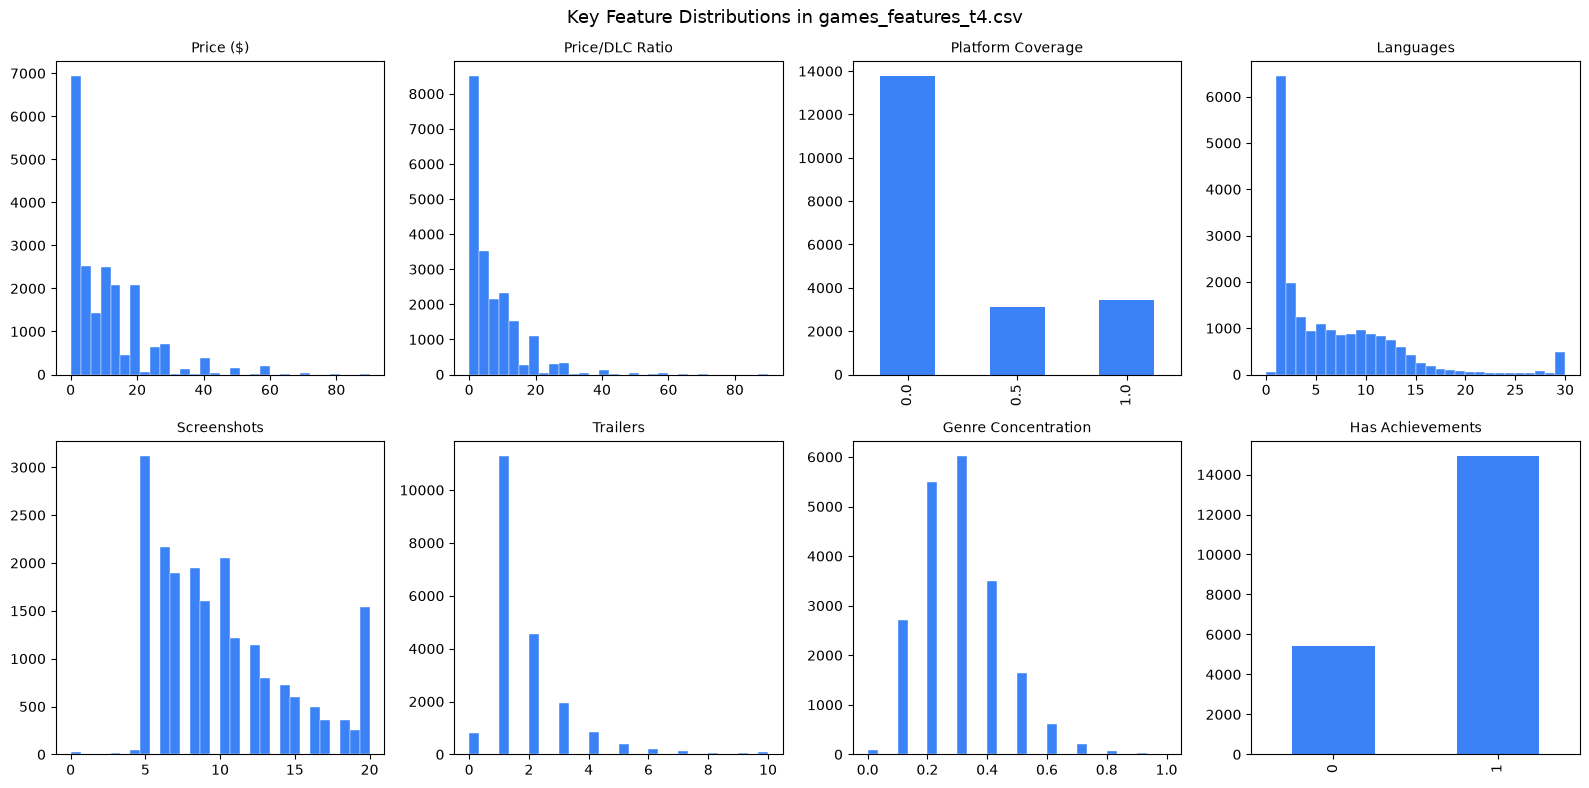

Saved: 02_feature_distributions.png


In [13]:
# ── Quick distribution check on key features ──────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Key Feature Distributions in games_features_t4.csv', fontsize=13)

features_to_plot = [
    (COL_PRICE,              'Price ($)'),
    ('price_to_dlc_ratio',   'Price/DLC Ratio'),
    ('platform_coverage',    'Platform Coverage'),
    ('supported_languages_count', 'Languages'),
    ('screenshot_count',     'Screenshots'),
    ('movie_count',          'Trailers'),
    ('genre_concentration',  'Genre Concentration'),
    ('has_achievements',     'Has Achievements'),
]

for ax, (col, label) in zip(axes.flat, features_to_plot):
    if df[col].nunique() <= 4:
        df[col].value_counts().sort_index().plot(kind='bar', ax=ax, color='#3b82f6')
    else:
        ax.hist(df[col], bins=30, color='#3b82f6', edgecolor='white', linewidth=0.3)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'outputs' / 'figures' / '02_feature_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_feature_distributions.png')
